In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage import io
from skimage.transform import resize
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import scipy.cluster.hierarchy as shc

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('weatherHistory.csv', skiprows=range(1, 23000), nrows=3000)

df = df.drop(['Formatted Date', 'Summary', 'Precip Type', 'Loud Cover'], axis=1)
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

label_enc = LabelEncoder()
ordinal_columns = df.select_dtypes('object').columns
for column in ordinal_columns:
    df[column] = label_enc.fit_transform(df[column])

iqr = df.quantile(0.75, numeric_only=True) - df.quantile(0.25, numeric_only=True)
lim = np.abs((df - df.median(numeric_only=True)) / iqr) < 2.22

df.loc[:, df.columns] = df.where(lim, np.nan)
df.dropna(inplace=True)

normalized_values = StandardScaler().fit_transform(df)
df = pd.DataFrame(normalized_values, columns=df.columns)

pca = PCA(2)
X = pca.fit_transform(df)

In [3]:
n_clusters = range(2, 11, 1)
clusters_scores = pd.DataFrame(columns=['N clusters', 'Hierarchical'])

hierarchical = AgglomerativeClustering()

for n in n_clusters:
    hierarchical = hierarchical.set_params(n_clusters=n)

    hierarchical_labels = hierarchical.fit_predict(df)
    sil_hierarchical = silhouette_score(df, hierarchical_labels)

    new_row = pd.DataFrame({"N clusters": [n], "Hierarchical": [sil_hierarchical]})
    clusters_scores = pd.concat([clusters_scores, new_row], ignore_index=True)

clusters_scores = clusters_scores.set_index('N clusters')
clusters_scores


,Hierarchical
N clusters,
2,0.167720
3,0.157936
4,0.128568
5,0.136686
6,0.134397
7,0.129585
8,0.134259
9,0.128966
10,0.111066


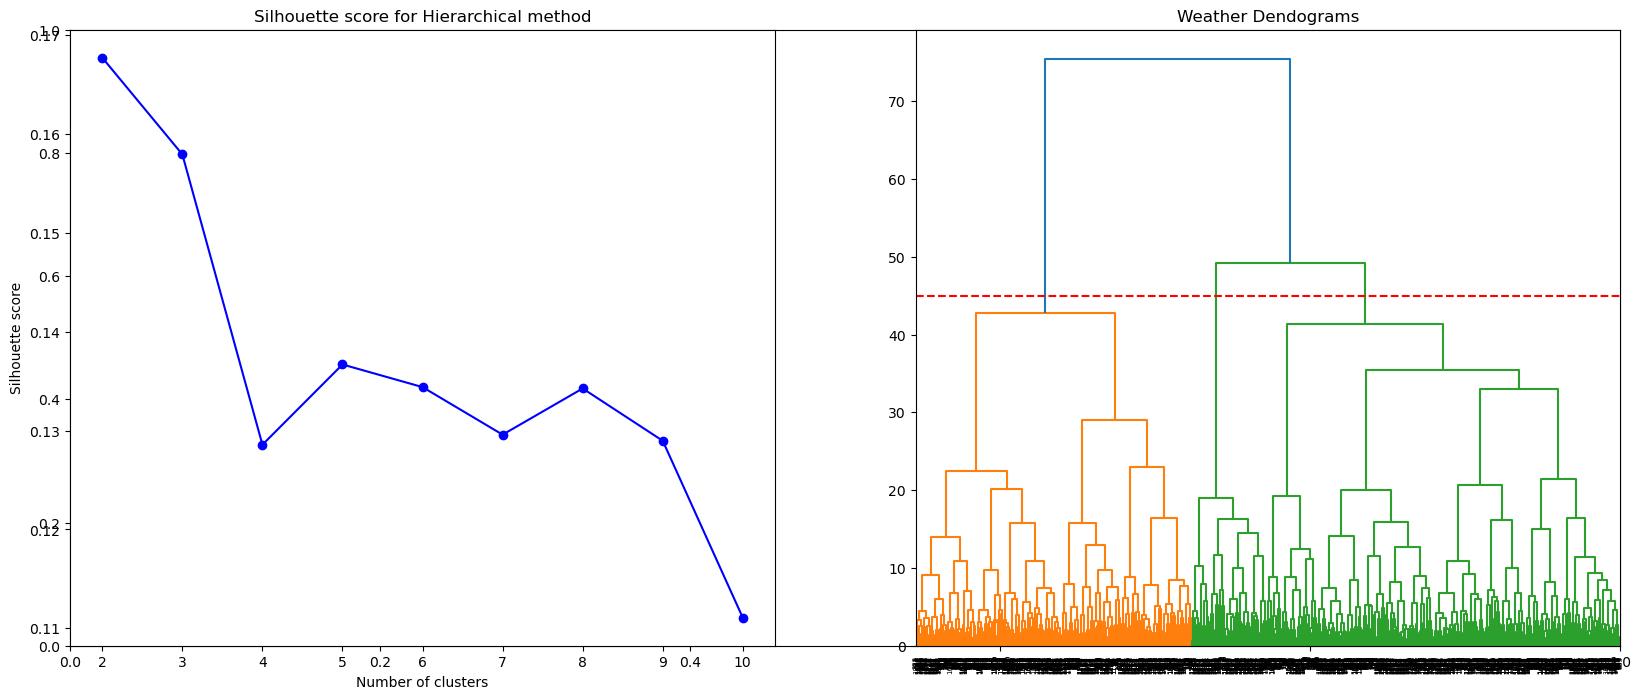

Optimal clusters via silhouette score: 2


In [4]:
plt.subplots(figsize=(20,8))
plt.subplot(1, 2, 1)
plt.plot(clusters_scores['Hierarchical'], 'bo-')
plt.title( f"Silhouette score for Hierarchical method")
    
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score') 

plt.subplot(1, 2, 2)
plt.title("Weather Dendograms") 
dend = shc.dendrogram(shc.linkage(df, method='ward'))
plt.axhline(y=45, color='r', linestyle="--")
plt.show()

hierarchical_sil_opt = clusters_scores['Hierarchical'].idxmax()
print(f"Optimal clusters via silhouette score: {hierarchical_sil_opt}")

Text(0.5, 1.0, 'Hierarchical with 2 clusters')

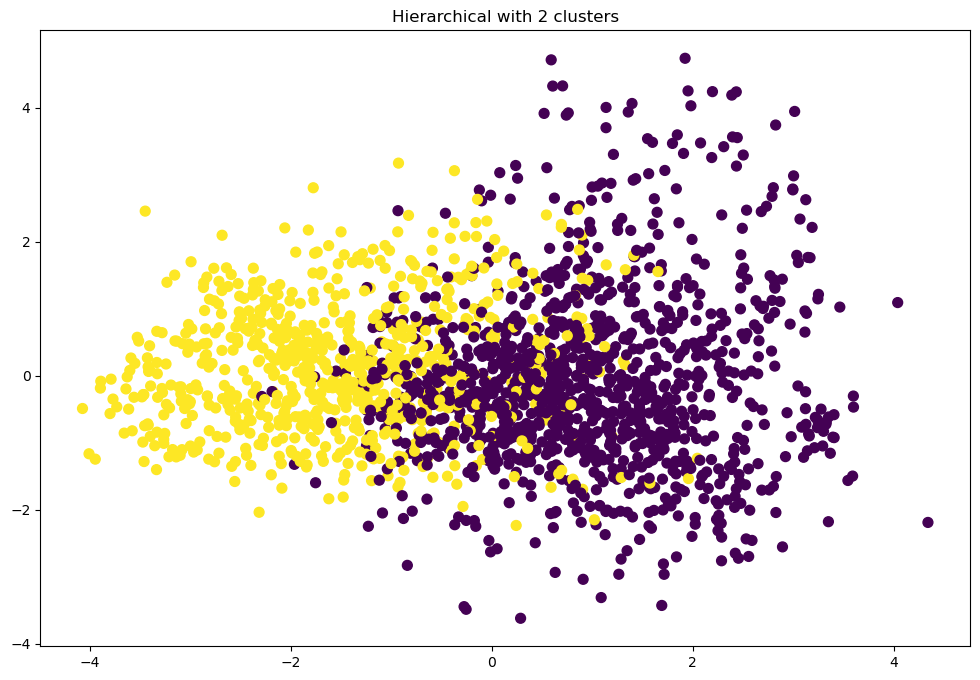

In [5]:
    hierarchical = hierarchical.set_params(n_clusters=hierarchical_sil_opt)
    y_hierarchical = hierarchical.fit_predict(df)

    plt.subplots(figsize=(12,8))
    plt.scatter(X[:, 0], X[:, 1], c=y_hierarchical, s=50, cmap='viridis')
    plt.title(f"Hierarchical with {hierarchical_sil_opt} clusters")

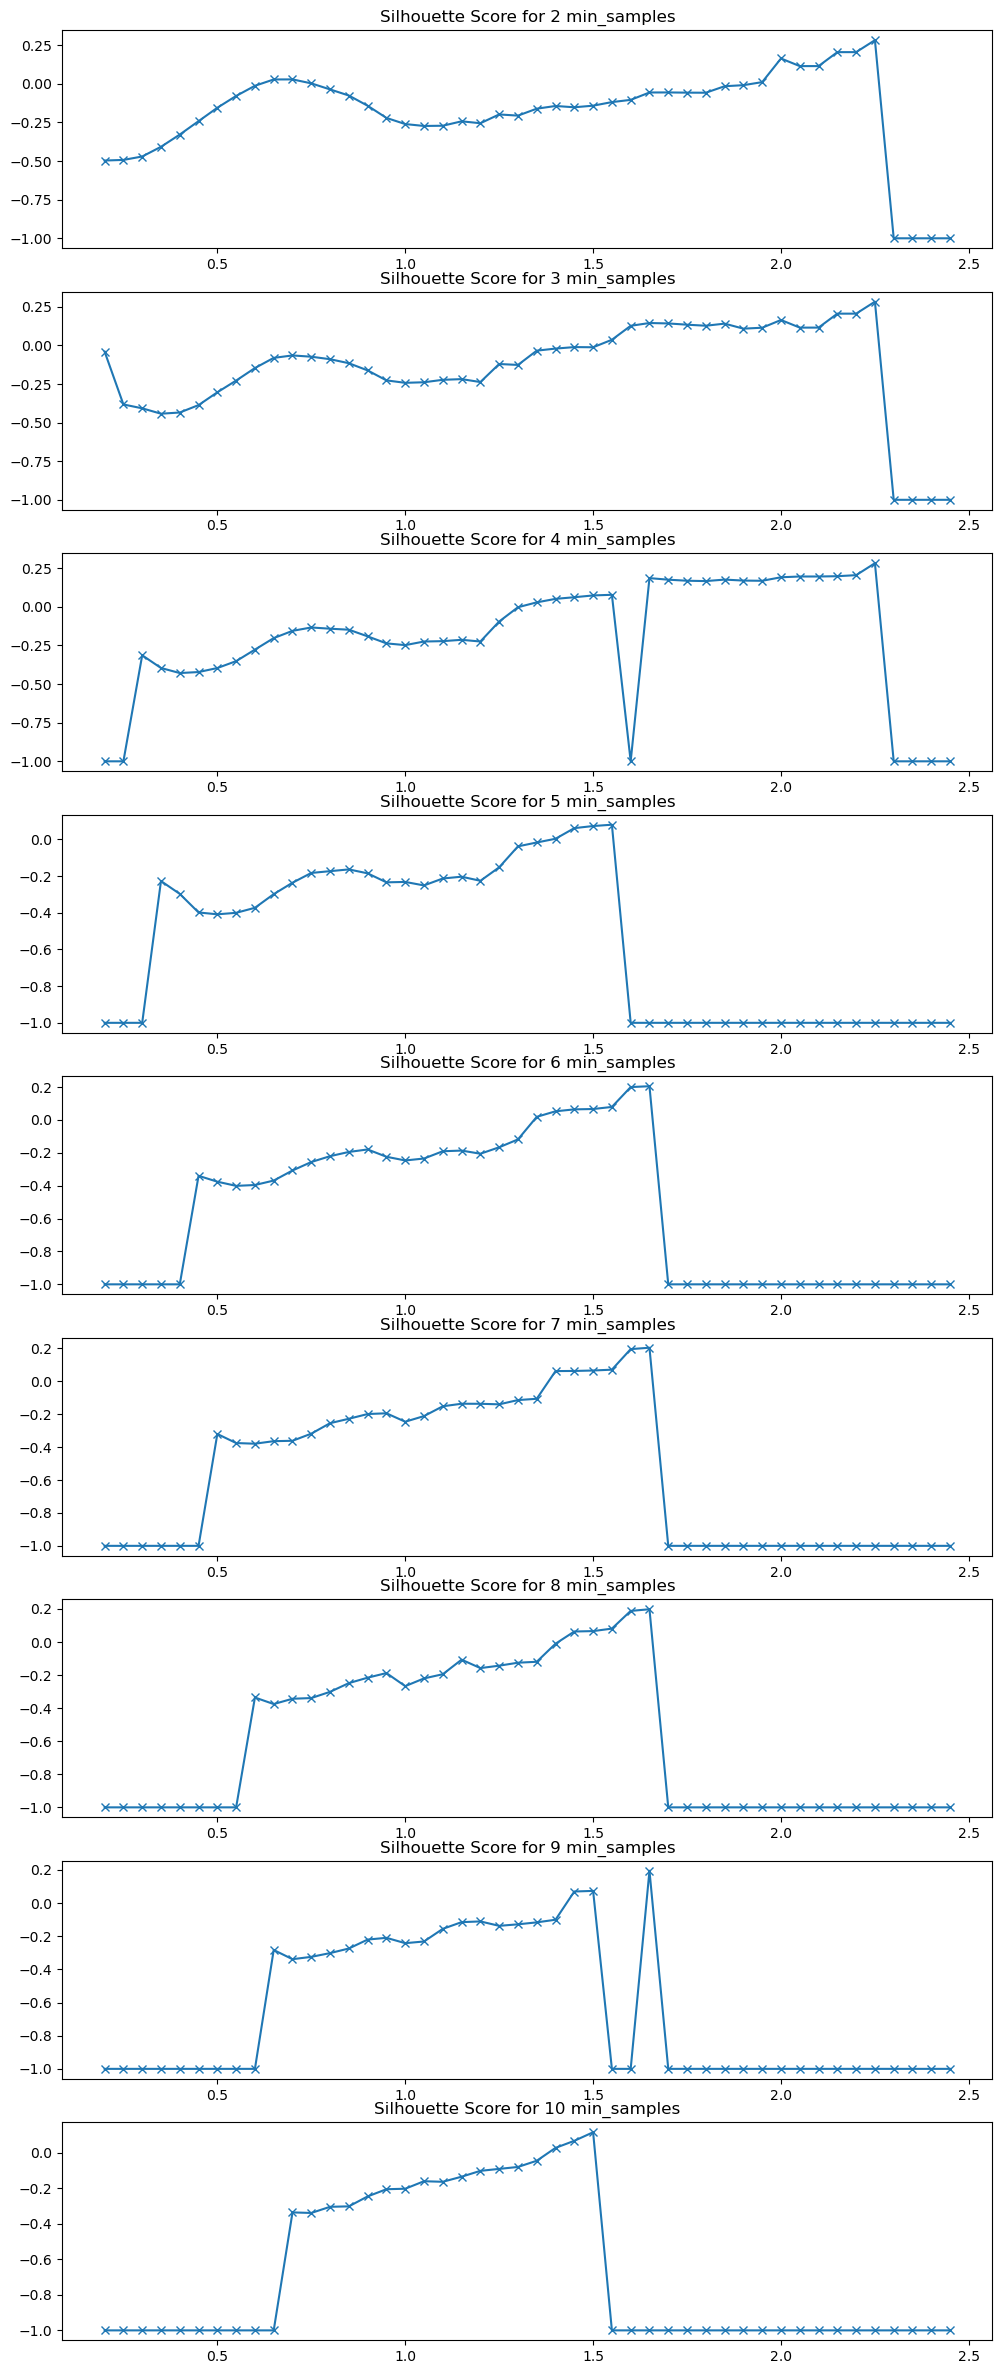

In [6]:
dbscan = DBSCAN()
dbscan_res = pd.DataFrame()
eps_range = np.arange(0.2, 2.5, 0.05)

fig, axs = plt.subplots(9, figsize=(12,30)) 

for n in n_clusters:
    sil_score = []

    for eps in eps_range:
        dbscan = DBSCAN(eps=eps, min_samples=n)
        y_dbscan = dbscan.fit_predict(df)
        clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)

        if clusters > 1:
            sil_score.append(silhouette_score(df, y_dbscan))
            new_row = pd.DataFrame({"Min samples": [int(n)], "Eps" : [eps], "DBSCAN": [silhouette_score(df, y_dbscan)]})
        else:
            sil_score.append(-1)
            new_row = pd.DataFrame({"Min samples": [int(n)], "Eps" : [eps],  "DBSCAN": [-1]})

        dbscan_res = pd.concat([dbscan_res, new_row], ignore_index=True)

    axs[n-2].plot(eps_range, sil_score, marker='x')
    axs[n-2].set_title(f'Silhouette Score for {n} min_samples')

plt.show()

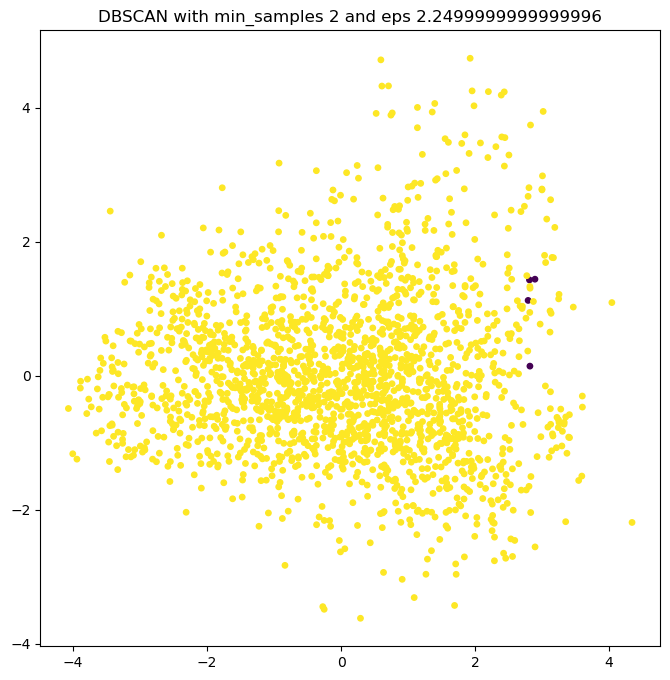

,Method,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,Hierarchical with 2 clusters,0.16772,436.682116,1.934190
1,DBSCAN with min_samples 2 and eps 2.2499999999...,0.28286,11.440415,0.717215


In [7]:
dbscan_idx = dbscan_res['DBSCAN'].idxmax()
dbscan_row = dbscan_res.iloc[dbscan_idx]
dbscan_eps = dbscan_row['Eps']
dbscan_samples = int(dbscan_row['Min samples'])

dbscan = DBSCAN(eps=dbscan_eps, min_samples=dbscan_samples)
y_dbscan = dbscan.fit_predict(df)

plt.figure(figsize=(8,8))
plt.scatter(X[:, 0], X[:, 1], c=y_dbscan, s=15, cmap='viridis')
plt.title( f"DBSCAN with min_samples {dbscan_samples} and eps {dbscan_eps}")
plt.show() 

clusters_est = pd.DataFrame()

hierarchical = hierarchical.set_params(n_clusters=hierarchical_sil_opt)
y_hierarchical = hierarchical.fit_predict(df)

new_row = pd.DataFrame({"Method" : [f'Hierarchical with {hierarchical_sil_opt} clusters', f'DBSCAN with min_samples {dbscan_samples} and eps {dbscan_eps}'], 
                            f"Silhouette Score": [silhouette_score(df, y_hierarchical), silhouette_score(df, y_dbscan)], 
                            "Calinski-Harabasz Index": [calinski_harabasz_score(df, y_hierarchical), calinski_harabasz_score(df, y_dbscan)], 
                            "Davies-Bouldin Index": [davies_bouldin_score(df, y_hierarchical), davies_bouldin_score(df, y_dbscan)]})
                            
clusters_est = pd.concat([clusters_est, new_row], ignore_index=True)

clusters_est

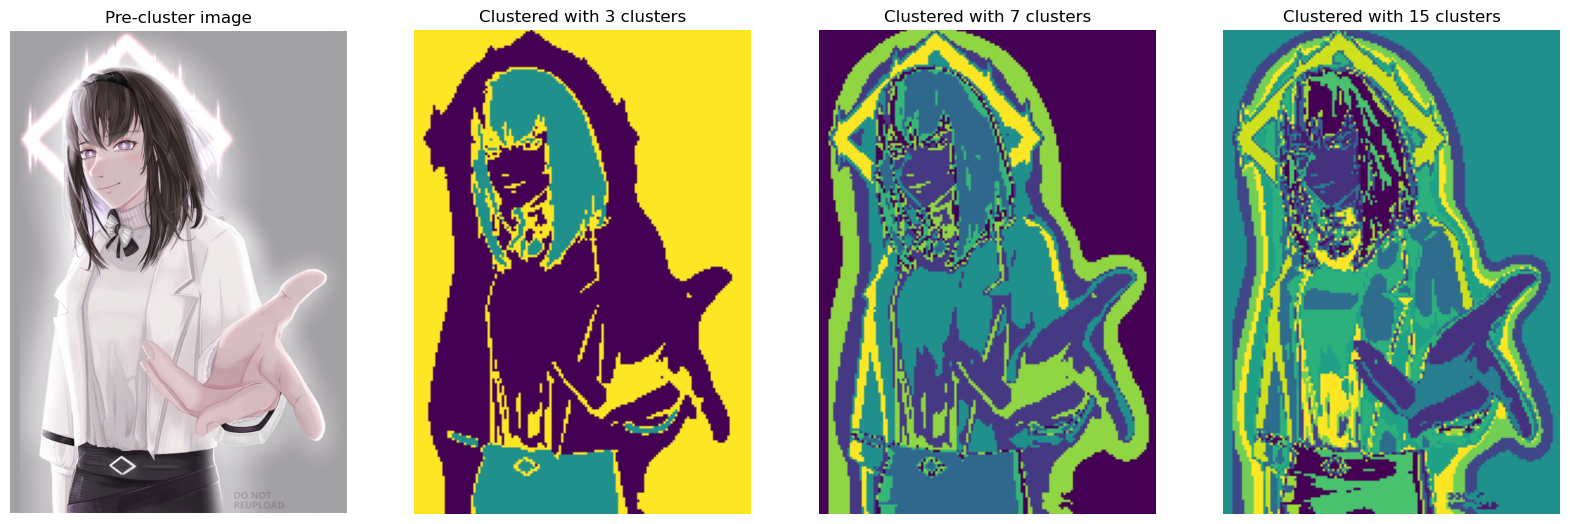

In [8]:
i=1
image = io.imread('priestess.jpg')
image = image / 255.0

resized_img = resize(image, (image.shape[0] // 7, image.shape[1] // 7))
pixels = resized_img.reshape((-1, 3)).astype(float)

scaler = StandardScaler()
pixels_scaled = scaler.fit_transform(pixels)

plt.figure(figsize=(20, 12))
plt.subplot(1, 4, i)
plt.imshow(image)
plt.title("Pre-cluster image")
plt.axis('off')

img_clusters = [3, 7, 15]

for n in img_clusters:
    i+=1
    hierarchical = hierarchical.set_params(n_clusters=n)
    image_labels = hierarchical.fit_predict(pixels_scaled)

    segmented_image = image_labels.reshape((resized_img.shape[0], resized_img.shape[1]))
    
    plt.subplot(1, 4, i)
    plt.imshow(segmented_image)
    plt.title(f"Clustered with {n} clusters")
    plt.axis('off')

plt.show()